<a href="https://www.kaggle.com/code/kathmer/bbc-news-analysis-ner-text-classification?scriptVersionId=309741427" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import kaggle
kaggle.api.authenticate()
print("Authenticated!")

Authenticated!


In [2]:
kaggle.api.dataset_download_files("gpreda/bbc-news", path='./data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/gpreda/bbc-news


In [3]:
import os
os.listdir('./data')

['bbc_news.csv']

In [4]:
df = pd.read_csv('./data/bbc_news.csv')

In [5]:
df.shape

(42115, 5)

In [6]:
print(df.head(3))

                                               title  \
0  Ukraine: Angry Zelensky vows to punish Russian...   
1  War in Ukraine: Taking cover in a town under a...   
2         Ukraine war 'catastrophic for global food'   

                         pubDate  \
0  Mon, 07 Mar 2022 08:01:56 GMT   
1  Sun, 06 Mar 2022 22:49:58 GMT   
2  Mon, 07 Mar 2022 00:14:42 GMT   

                                               guid  \
0  https://www.bbc.co.uk/news/world-europe-60638042   
1  https://www.bbc.co.uk/news/world-europe-60641873   
2      https://www.bbc.co.uk/news/business-60623941   

                                                link  \
0  https://www.bbc.co.uk/news/world-europe-606380...   
1  https://www.bbc.co.uk/news/world-europe-606418...   
2  https://www.bbc.co.uk/news/business-60623941?a...   

                                         description  
0  The Ukrainian president says the country will ...  
1  Jeremy Bowen was on the frontline in Irpin, as...  
2  One of the world

In [7]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [8]:
def get_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df.description.apply(get_entities)

print(df['entities'].head())

0                                  [(Ukrainian, NORP)]
1    [(Jeremy Bowen, PERSON), (Irpin, GPE), (Russia...
2                                    [(One, CARDINAL)]
3                         [(Manchester Arena, PERSON)]
4                                                   []
Name: entities, dtype: object


In [9]:
from collections import Counter

all_entities = []
for entities in df['entities']:
    for ent_text, ent_label in entities:
        all_entities.append((ent_text, ent_label))

counter = Counter(all_entities)
print(counter.most_common(20))

[(('England', 'GPE'), 2021), (('first', 'ORDINAL'), 1794), (('UK', 'GPE'), 1657), (('BBC', 'ORG'), 1639), (('US', 'GPE'), 1038), (('Ukraine', 'GPE'), 983), (('two', 'CARDINAL'), 835), (('one', 'CARDINAL'), 725), (('Russia', 'GPE'), 700), (('Russian', 'NORP'), 603), (('second', 'ORDINAL'), 515), (('London', 'GPE'), 487), (('Israel', 'GPE'), 477), (('three', 'CARDINAL'), 442), (('Saturday', 'DATE'), 430), (('Sunday', 'DATE'), 426), (('British', 'NORP'), 419), (('Scotland', 'GPE'), 414), (('World Cup', 'EVENT'), 406), (('Labour', 'ORG'), 370)]


In [10]:
print(counter.most_common(20))

[(('England', 'GPE'), 2021), (('first', 'ORDINAL'), 1794), (('UK', 'GPE'), 1657), (('BBC', 'ORG'), 1639), (('US', 'GPE'), 1038), (('Ukraine', 'GPE'), 983), (('two', 'CARDINAL'), 835), (('one', 'CARDINAL'), 725), (('Russia', 'GPE'), 700), (('Russian', 'NORP'), 603), (('second', 'ORDINAL'), 515), (('London', 'GPE'), 487), (('Israel', 'GPE'), 477), (('three', 'CARDINAL'), 442), (('Saturday', 'DATE'), 430), (('Sunday', 'DATE'), 426), (('British', 'NORP'), 419), (('Scotland', 'GPE'), 414), (('World Cup', 'EVENT'), 406), (('Labour', 'ORG'), 370)]


Dominating subjects:

England, UK, London, Scotland — heavy domestic coverage as expected for BBC
Ukraine, Russia — dataset is from March 2022, right at the start of the war
US, Israel — major international stories
BBC itself appears 1,639 times — reporters referencing their own outlet
World Cup — big sports story at the time
Labour — UK politics

And a lot of noise like 'first', spaCy is not tagging them correctly

# Meaningful entities

In [11]:
meaningful = ['PERSON', 'ORG', 'GPE', 'EVENT', 'NORP']

filtered = [(text, label) for text, label in all_entities if label in meaningful]
counter_filtered = Counter(filtered)
print(counter_filtered.most_common(20))

[(('England', 'GPE'), 2021), (('UK', 'GPE'), 1657), (('BBC', 'ORG'), 1639), (('US', 'GPE'), 1038), (('Ukraine', 'GPE'), 983), (('Russia', 'GPE'), 700), (('Russian', 'NORP'), 603), (('London', 'GPE'), 487), (('Israel', 'GPE'), 477), (('British', 'NORP'), 419), (('Scotland', 'GPE'), 414), (('World Cup', 'EVENT'), 406), (('Labour', 'ORG'), 370), (('Manchester City', 'GPE'), 363), (('France', 'GPE'), 357), (('Gaza', 'GPE'), 353), (('Australia', 'GPE'), 320), (('Manchester United', 'PERSON'), 306), (('Chelsea', 'ORG'), 302), (('Wales', 'GPE'), 283)]


England dominates (2021 mentions) — lots of sport and domestic news
Ukraine + Russia (983 + 700) — the war is a major theme
Manchester City tagged as GPE (location) and Manchester United as PERSON — spaCy errors, both should be ORG
World Cup (406) — big sports story
Gaza (353) — conflict coverage
Chelsea, Labour correctly tagged as ORG

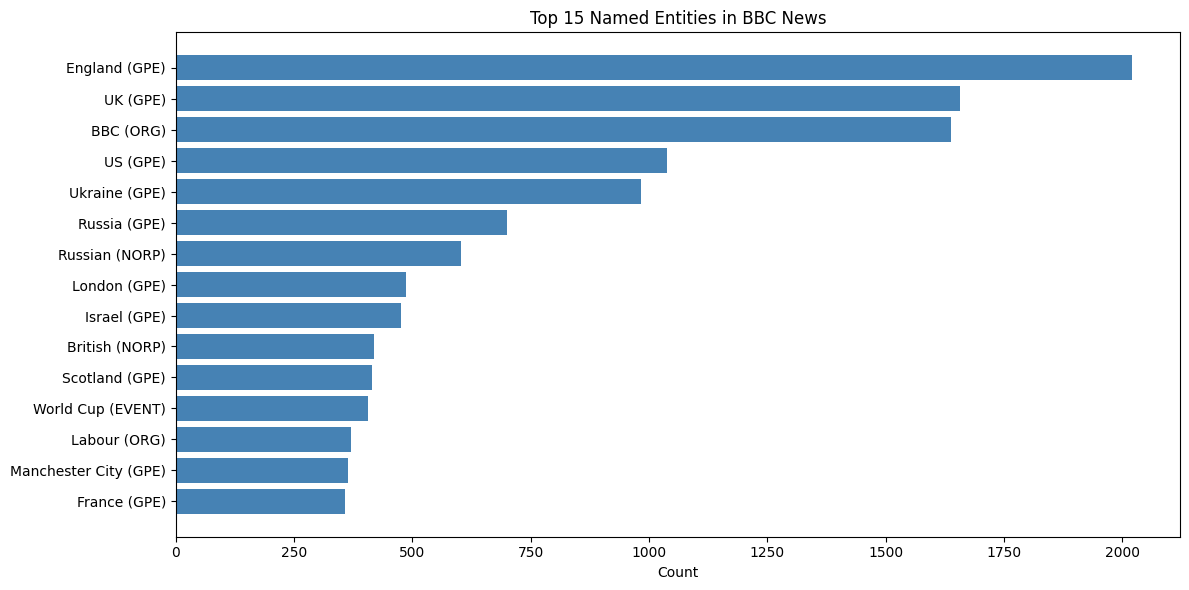

In [12]:
import matplotlib.pyplot as plt

top15 = counter_filtered.most_common(15)
labels = [f"{text} ({label})" for text, label in [x[0] for x in top15]]
counts = [x[1] for x in top15]

plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], counts[::-1], color='steelblue')
plt.title('Top 15 Named Entities in BBC News')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# People

In [13]:
people = [(text, label) for text, label in all_entities if label == 'PERSON']
people_counter = Counter(people)
print(people_counter.most_common(15))

[(('Manchester United', 'PERSON'), 306), (('Rishi Sunak', 'PERSON'), 225), (('Covid', 'PERSON'), 143), (('Boris Johnson', 'PERSON'), 130), (('Keir Starmer', 'PERSON'), 113), (('Queen', 'PERSON'), 105), (('Andy Murray', 'PERSON'), 100), (('Phil McNulty', 'PERSON'), 98), (('Gareth Southgate', 'PERSON'), 94), (('Donald Trump', 'PERSON'), 91), (('Liz Truss', 'PERSON'), 89), (('Putin', 'PERSON'), 87), (('Emma Raducanu', 'PERSON'), 79), (('Max Verstappen', 'PERSON'), 78), (('Erik', 'PERSON'), 78)]


Rishi Sunak, Boris Johnson, Keir Starmer, Liz Truss — UK politics heavily covered, this was a turbulent period for UK government
Putin (87) — Ukraine war
Andy Murray, Gareth Southgate, Emma Raducanu, Max Verstappen — big sports figures
The Queen (105) — likely around her death in September 2022


Errors from spaCy:

Manchester United tagged as PERSON — should be ORG
Covid tagged as PERSON
Erik — too short to identify

# Organisations

In [14]:
orgs = [(text, label) for text, label in all_entities if label == 'ORG']
org_counter = Counter(orgs)
print(org_counter.most_common(15))

[(('BBC', 'ORG'), 1639), (('Labour', 'ORG'), 370), (('Chelsea', 'ORG'), 302), (('BBC Sport', 'ORG'), 264), (('Hamas', 'ORG'), 250), (('Liverpool', 'ORG'), 226), (('NHS', 'ORG'), 202), (('Champions League', 'ORG'), 162), (('Premier League', 'ORG'), 153), (('Arsenal', 'ORG'), 141), (('UN', 'ORG'), 134), (('EU', 'ORG'), 129), (('the Premier League', 'ORG'), 125), (('Wales', 'ORG'), 111), (('SNP', 'ORG'), 99)]


BBC + BBC Sport (1639 + 264) — self-references
Labour, SNP — UK politics
Chelsea, Liverpool, Arsenal, Champions League, Premier League — football dominates sports coverage
Hamas (250) — Gaza conflict
NHS (202) — UK health coverage
UN, EU — international organisations

# Adding a classifier that predicts article category

In [15]:
df['category'] = df['link'].str.extract(r'/news/([a-z\-]+)-\d+')
print(df['category'].value_counts().head(20))

category
uk                     2919
world-europe           2644
business               2643
world-us-canada        2005
entertainment-arts     1863
uk-politics            1736
world-middle-east      1110
uk-wales                721
health                  688
world-asia              635
blogs-the-papers        614
science-environment     562
world-africa            562
uk-england-london       549
world                   487
technology              430
uk-scotland             426
newsbeat                402
uk-northern-ireland     369
education               283
Name: count, dtype: int64


In [16]:
def simplify_category(cat):
    if not isinstance(cat, str):
        return None
    if 'sport' in cat:
        return 'sport'
    elif 'world' in cat:
        return 'world'
    elif 'uk' in cat or 'politics' in cat:
        return 'uk'
    elif cat in ['business', 'technology', 'science-environment']:
        return 'business-tech'
    elif cat in ['entertainment-arts', 'newsbeat']:
        return 'entertainment'
    elif cat in ['health', 'education']:
        return 'health-education'
    else:
        return 'other'

df['category'] = df['link'].str.extract(r'/news/([a-z\-]+)-\d+')
df.loc[df['link'].str.contains('/sport/', na=False), 'category'] = 'sport'

df['category_simple'] = df['category'].apply(simplify_category)
print(df['category_simple'].value_counts())

category_simple
uk                  9665
sport               8395
world               8367
business-tech       3635
entertainment       2265
other               1054
health-education     971
Name: count, dtype: int64


TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [18]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

df_clean = df.dropna(subset=['category_simple', 'description'])

X = tfidf.fit_transform(df_clean['description'])
y = df_clean['category_simple']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [19]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(max_iter=1000, class_weight='balanced')

lg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [20]:
y_pred = lg.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7485082229660893
                  precision    recall  f1-score   support

   business-tech       0.60      0.74      0.66       716
   entertainment       0.53      0.74      0.61       439
health-education       0.42      0.69      0.52       213
           other       0.72      0.75      0.74       199
           sport       0.95      0.94      0.95      1721
              uk       0.75      0.62      0.68      1898
           world       0.78      0.71      0.74      1685

        accuracy                           0.75      6871
       macro avg       0.68      0.74      0.70      6871
    weighted avg       0.77      0.75      0.75      6871



Key highlights:

Sport (95% precision, 94% recall) — near perfect, sports articles have very distinctive vocabulary
World (78%) and UK (75%) — good performance
Health-education (42% precision) — weakest class, often confused with UK and world news
Entertainment (53% precision) — hard to distinguish from other categories

# Classifier with NER results

In [21]:
def entities_to_string(entities):
    return ' '.join([text for text, label in entities])

df_clean['entity_str'] = df_clean['entities'].apply(entities_to_string)
print(df_clean['entity_str'].head(3))

0                     Ukrainian
1    Jeremy Bowen Irpin Russian
2                           One
Name: entity_str, dtype: object


/tmp/ipykernel_17/2357872549.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['entity_str'] = df_clean['entities'].apply(entities_to_string)


In [22]:
X = tfidf.fit_transform(df_clean['entity_str'])
y = df_clean['category_simple']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [23]:
lg1 = LogisticRegression(max_iter=1000, class_weight='balanced')

lg1.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [24]:
y_pred = lg.predict(X_test)

In [25]:

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.22747780526851988
                  precision    recall  f1-score   support

   business-tech       0.09      0.07      0.08       716
   entertainment       0.08      0.05      0.06       439
health-education       0.02      0.03      0.02       213
           other       0.04      0.04      0.04       199
           sport       0.34      0.04      0.08      1721
              uk       0.27      0.51      0.35      1898
           world       0.25      0.26      0.26      1685

        accuracy                           0.23      6871
       macro avg       0.15      0.14      0.13      6871
    weighted avg       0.24      0.23      0.19      6871



Failure

Entities are too sparse — many articles only have 1-2 entities (like row 0: just "Ukrainian", row 2: just "One")
Entities overlap across categories — "UK", "Russia", "Boris Johnson" appear in sport, world AND politics articles
spaCy errors hurt more here — when "Covid" is tagged as PERSON and "Manchester United" as PERSON

The lesson:
Raw text contains much richer signal than extracted entities alone. Words like "penalty", "parliament", "diagnosis" are strong category predictors that NER throws away.

In this project, I applied Named Entity Recognition (NER) and text classification on 42,115 BBC News articles.

**What I did:**
- Extracted article categories from URLs (UK, World, Sport, Business-Tech, Entertainment, Health-Education)
- Applied spaCy's pre-trained NER model to identify people, organisations, locations and events
- Analysed the most frequent entities across all categories
- Built a Logistic Regression classifier to predict article category from description text using TF-IDF + bigrams — achieved 75% accuracy across 6 categories
- Tested a second classifier using only NER entities as features to compare against full text

**Key NER findings:**
- England, UK and London dominate location coverage — BBC is heavily domestic
- Ukraine and Russia appear 983 and 700 times — dataset captures the early 2022 invasion
- Rishi Sunak, Boris Johnson and Keir Starmer are the most mentioned politicians
- Football clubs (Chelsea, Liverpool, Arsenal) and political organisations (Labour, SNP, NHS) dominate the ORG category

**Classification results:**
- Full text TF-IDF: 75% accuracy across 6 categories
- Entities only: 23% accuracy
- Sport was the easiest category to predict (95% precision) — highly distinctive vocabulary
- Health-education was the hardest (42% precision) — overlaps with UK and world news

**Key insight:**
Context words carry as much predictive power as named entities. Words like "penalty", "parliament" and "diagnosis" are strong category signals that NER discards. Entities are valuable for information extraction but not sufficient alone for classification.

**spaCy limitations observed:**
- Manchester United tagged as PERSON instead of ORG
- Covid tagged as PERSON — pre-trained models struggle with new proper nouns
- "Premier League" and "the Premier League" counted as separate entities

**Next steps:**
- Fine-tune spaCy on news-specific data to reduce entity errors
- Combine entities and full text as features
- Experiment with more article categories